# Prediction of time series with a seasonal component

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.api import ExponentialSmoothing

In [2]:
# Load the data
co2 = pd.read_csv('./CO2_data.csv', index_col=0)
co2.index = pd.to_datetime(co2.index)
co2

,CO2
1995-01-31,315.42
1995-02-28,316.31
1995-03-31,316.50
1995-04-30,317.56
1995-05-31,318.13
...,...
2019-08-31,342.21
2019-09-30,339.69
2019-10-31,339.82
2019-11-30,340.98


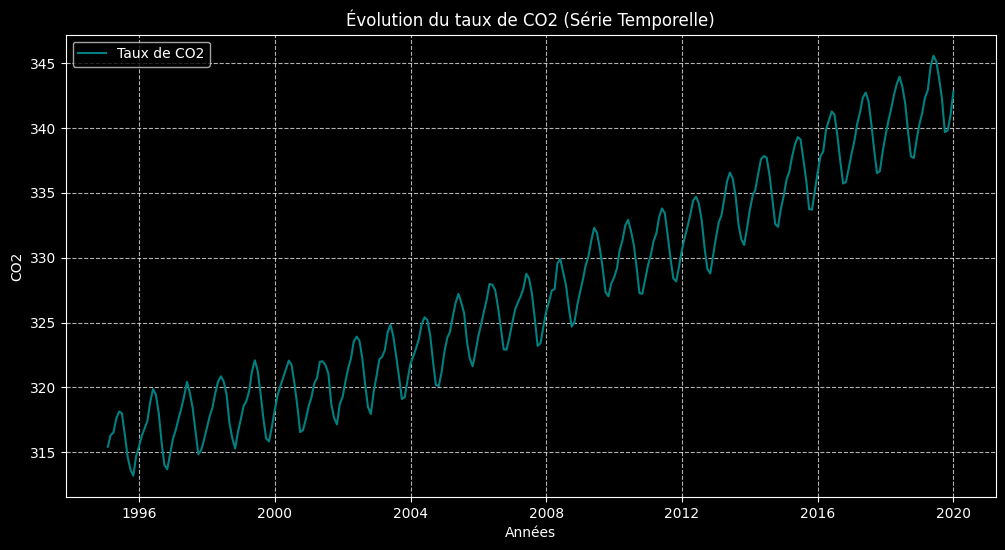

In [3]:
df = pd.read_csv('CO2_data.csv', index_col=0, parse_dates=True)

# 2. Visualisation
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['CO2'], label='Taux de CO2', color='teal')
plt.title('Évolution du taux de CO2 (Série Temporelle)')
plt.xlabel('Années')
plt.ylabel('CO2')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

Une Tendance Haussière : Le niveau global de CO2 augmente d'année en année.

Une Saisonnalité Marquée : Des oscillations régulières se répètent chaque année (pics et creux), ce qui confirme la présence d'une composante saisonnière.

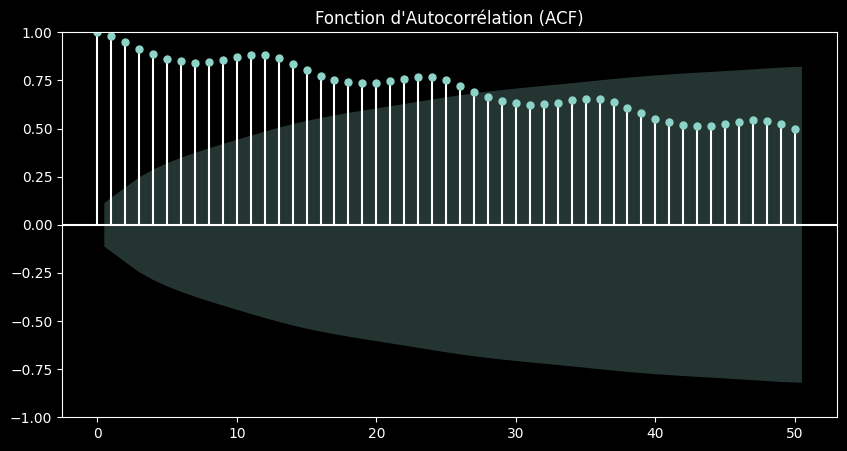

In [4]:
# Affichage de l'ACF sur 50 lags (environ 4 ans de données mensuelles)
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(df['CO2'], lags=50, ax=ax)
plt.title("Fonction d'Autocorrélation (ACF)")
plt.show()

In [5]:
from abc import ABC, abstractmethod
from statsmodels.tsa.stattools import acf


# Interface
class SeasonalityStrategy(ABC):
    @abstractmethod
    def detect_period(self, series: pd.Series) -> int:
        pass


# Implémentation concrète via l'Autocorrélation (ACF)
class ACFSeasonalityStrategy(SeasonalityStrategy):
    def detect_period(self, series: pd.Series) -> int:
        # On différencie pour retirer la tendance (Stationnarisation)
        diff_series = series.diff().dropna()
        # On cherche le pic dans une plage raisonnable (ex: 4 à 24 mois)
        acf_values = acf(diff_series, nlags=24)
        # On ignore les premiers lags (corrélation de voisinage)
        return 4 + acf_values[4:].argmax()


# Contexte (Utilisateur de la stratégie)
class TimeSeriesAnalyzer:
    def __init__(self, strategy: SeasonalityStrategy):
        self._strategy = strategy

    def get_seasonality(self, data: pd.Series):
        return self._strategy.detect_period(data)


# Utilisation
analyzer = TimeSeriesAnalyzer(ACFSeasonalityStrategy())
period = analyzer.get_seasonality(df['CO2'])
print(f"La période saisonnière détectée est : {period}")

La période saisonnière détectée est : 12


L'ACF confirme sans ambiguïté la présence d'une tendance très forte. En effet :
- Décroissance très lente : Les coefficients d'autocorrélation ne tombent pas rapidement vers zéro. Ils restent élevés (>0.8) même après plusieurs années (plus de 12 ou 24 lags).
- Signature du non-stationnaire : Une série "stationnaire" (sans tendance) voit son ACF s'effondrer immédiatement. Cette décroissance linéaire et lente est le signe mathématique classique d'une série non-stationnaire avec une tendance monotone.


In [6]:
def split_data(df: pd.DataFrame, val_size: int):
    """Découpe les données en gardant les derniers points pour la validation."""
    train = df.iloc[:-val_size]
    validation = df.iloc[-val_size:]
    return train, validation


# Application du split (48 derniers points pour la validation)
co2_train, val = split_data(df, val_size=48)

# Vérification
print(f"Nombre de points total : {len(df)}")
print(f"Entraînement : {len(co2_train)} points")
print(f"Validation : {len(val)} points")

Nombre de points total : 300
Entraînement : 252 points
Validation : 48 points


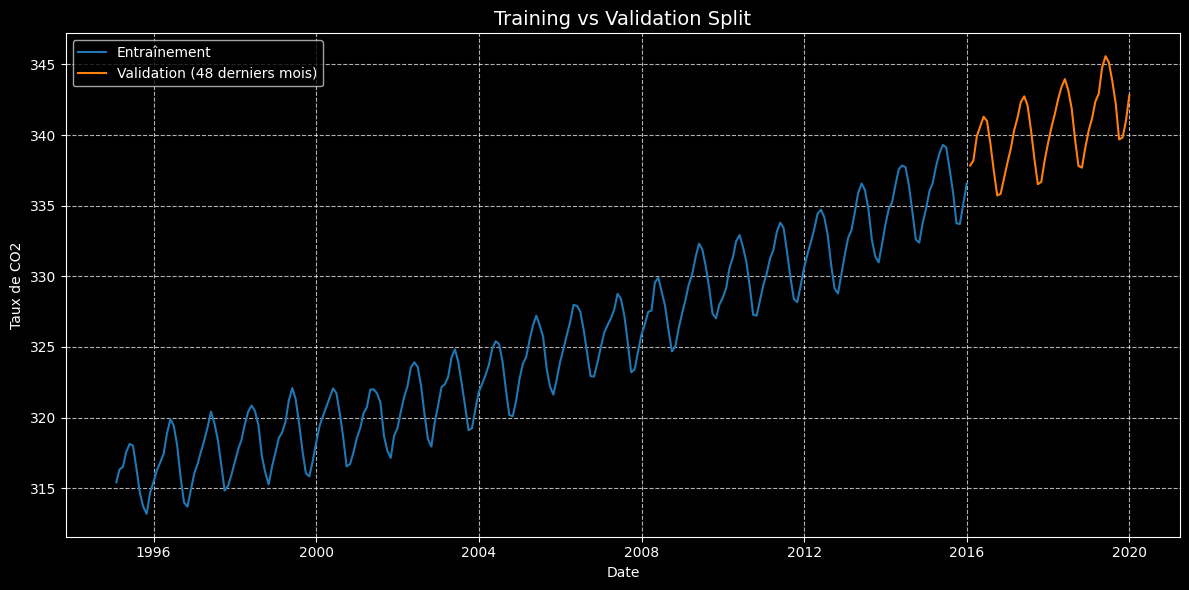

In [7]:
class TimeSeriesPlotter:
    """Classe dédiée à la visualisation (SRP)."""

    @staticmethod
    def plot_split(train, val, title="Training vs Validation Split"):
        plt.figure(figsize=(12, 6))

        # Plot des deux sets
        plt.plot(train.index, train['CO2'], label='Entraînement', color='#1f77b4', linewidth=1.5)
        plt.plot(val.index, val['CO2'], label='Validation (48 derniers mois)', color='#ff7f0e', linewidth=1.5)

        # Mise en forme
        plt.title(title, fontsize=14)
        plt.xlabel('Date')
        plt.ylabel('Taux de CO2')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()


# Utilisation
TimeSeriesPlotter.plot_split(co2_train, val)

In [8]:
# We will now apply the Triple Exponential Smoothing algorithm to the training data (additive model first)
# As you can see below, we need to indicate the length of the period in 'seasonal_periods', and 
# we specify sesaonal = 'add' for an additive model (trend will always be 'add' for us)
tes_model = ExponentialSmoothing(co2_train, initialization_method='estimated', seasonal_periods=12, trend='add', seasonal='add').fit()
tes_model.summary()

C:\Users\mihan\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


Dep. Variable:,CO2,No. Observations:,252
Model:,ExponentialSmoothing,SSE,17.616
Optimized:,True,AIC,-638.477
Trend:,Additive,BIC,-582.007
Seasonal:,Additive,AICC,-635.542
Seasonal Periods:,12,Date:,"Thu, 19 Feb 2026"
Box-Cox:,False,Time:,09:15:45
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.6506044,alpha,True
smoothing_trend,0.000000,beta,True


In [9]:
# To see the evolution of the parameter a throughout the TES algorithm you can ask:
tes_model.level

1995-01-31    315.512790
1995-02-28    315.717172
1995-03-31    315.463035
1995-04-30    315.361916
1995-05-31    315.377151
                 ...    
2015-08-31    336.992036
2015-09-30    336.768920
2015-10-31    336.843777
2015-11-30    337.064261
2015-12-31    337.403780
Length: 252, dtype: float64

In [17]:
# To see the evolution of the parameter b throughout the TES algorithm you can ask:
tes_model.trend

1995-01-31    0.087528
1995-02-28    0.087528
1995-03-31    0.087528
1995-04-30    0.087528
1995-05-31    0.087528
                ...   
2015-08-31    0.087528
2015-09-30    0.087528
2015-10-31    0.087528
2015-11-30    0.087528
2015-12-31    0.087528
Length: 252, dtype: float64

In [18]:
# To see the evolution of the seasonal coefficients throughout the TES algorithm you can ask:
tes_model.season

1995-01-31    0.998749
1995-02-28    1.000679
1995-03-31    1.002808
1995-04-30    1.006124
1995-05-31    1.007630
                ...   
2015-08-31    0.995524
2015-09-30    0.990280
2015-10-31    0.989408
2015-11-30    0.992852
2015-12-31    0.996037
Length: 252, dtype: float64

In [19]:
# 1. Extraction brute des coefficients
seasonal_coeffs = tes_model.params['initial_seasons']

# 2. Création d'un DataFrame pour une présentation propre (Optionnel mais recommandé)
# On crée un index pour les 12 mois
months = ['Janvier', 'Février', 'Mars', 'Avril', 'Mai', 'Juin',
          'Juillet', 'Août', 'Septembre', 'Octobre', 'Novembre', 'Décembre']

df_seasonal = pd.DataFrame({
    'Mois': months,
    'Coefficient': seasonal_coeffs
})

# 3. Affichage
print(df_seasonal)

         Mois  Coefficient
0     Janvier     0.998749
1     Février     1.000679
2        Mars     1.002808
3       Avril     1.006124
4         Mai     1.007630
5        Juin     1.005905
6     Juillet     1.001672
7        Août     0.995524
8   Septembre     0.990280
9     Octobre     0.989408
10   Novembre     0.992852
11   Décembre     0.996037


In [12]:
# These predictions can be obtained by the following command : 
tes_model.forecast(2)

2016-01-31    337.393442
2016-02-29    338.108205
Freq: ME, dtype: float64

In [13]:
# We will now try a model with a multiplicative seasonal composant. 
# For this, you need to specify seasonal = 'mul' in the call of the Exponenatial smoothing function : 
tes_model = ExponentialSmoothing(co2_train, initialization_method='estimated', seasonal_periods=12, trend='add',
                                 seasonal='mul').fit()
tes_model.summary()

C:\Users\mihan\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


Dep. Variable:,CO2,No. Observations:,252
Model:,ExponentialSmoothing,SSE,17.300
Optimized:,True,AIC,-643.040
Trend:,Additive,BIC,-586.569
Seasonal:,Multiplicative,AICC,-640.104
Seasonal Periods:,12,Date:,"Thu, 19 Feb 2026"
Box-Cox:,False,Time:,09:15:46
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.6307395,alpha,True
smoothing_trend,0.000000,beta,True


In [14]:
# These predictions can be obtained by the command:
tes_model.forecast(2)

2016-01-31    337.436331
2016-02-29    338.175965
Freq: ME, dtype: float64

## Classical AutoRegressive models (no trend no season)

## AutoRegressive models with trend

## AutoRegressive models with seasonal component

In [15]:
# We will now apply a seasonal AR model of order 1 without trend (to start):
# For this, you need to specify seasonal = True and to indicate the period of the seasonal component (12 here)
ARS = AutoReg(co2_train, lags=1, trend='c', seasonal=True, period=12).fit()
ARS.summary()

C:\Users\mihan\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            AutoReg Model Results                             
==============================================================================
Dep. Variable:                    CO2   No. Observations:                  252
Model:               Seas. AutoReg(1)   Log Likelihood                 -35.315
Method:               Conditional MLE   S.D. of innovations              0.279
Date:                Thu, 19 Feb 2026   AIC                             98.629
Time:                        09:15:46   BIC                            147.986
Sample:                    02-28-1995   HQIC                           118.491
                         - 12-31-2015                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1829      0.910      0.201      0.841      -1.601       1.967
s(2,12)       -0.2615      0.087     -3.005      0.003      -0.432      -0.091
s(3,12)       -0.2004      0.087     -2.301      0.021      -0.371      -0.030
s(4,12)        0.1863      0.087      2.136      0.033       0.015       0.357
s(5,12)       -0.4033      0.087     -4.610      0.000      -0.575      -0.232
s(6,12)       -1.4575      0.088    -16.627      0.000      -1.629      -1.286
s(7,12)       -2.2721      0.088    -25.964      0.000      -2.444      -2.101
s(8,12)       -2.8942      0.087    -33.189      0.000      -3.065      -2.723
s(9,12)       -2.5933      0.087    -29.800      0.000      -2.764      -2.423
s(10,12)      -1.1689      0.087    -13.415      0.000      -1.340      -0.998
s(11,12)       0.2378      0.087      2.728      0.006       0.067       0.409
s(12,12)       0.1501      0.087      1.724      0.085      -0.021       0.321
CO2.L1         1.0024      0.003    357.539      0.000       0.997       1.008
                                    Roots                                    
=============================================================================
                  Real          Imaginary           Modulus         Frequency
-----------------------------------------------------------------------------
AR.1            0.9976           +0.0000j            0.9976            0.0000
-----------------------------------------------------------------------------
"""

In [16]:
#These values can be obtained by the following command:
ARS.forecast(2)

C:\Users\mihan\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)
C:\Users\mihan\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\deterministic.py:441: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


2016-01-31    337.565977
2016-02-29    338.312892
Freq: ME, dtype: float64